In [3]:
from pyloco import pyloco, remove_bad_bpms, plot_data
import numpy as np
import at
ring = at.load_lattice('p3_low_beta.mat')
elements_ind = at.get_refpts(ring, "*")
_, _, twiss = at.get_optics(ring, elements_ind)
# ============================================================================== #
#                Prepare quadrupoles,skews, correctors, bpms, cavity indices
# ============================================================================== #

quad_indices = np.load('./data/quad_ind.npy')
skew_ord = np.load('./data/skew_ind.npy')

data = np.load('./data/CMstep.npz')
CMstep = [data['hor'], data['ver']]

def load_names(filename):
    with open(filename, 'r') as file:
        names = [line.strip() for line in file.readlines()]
    return names

HCM_names = load_names("./data/HCM_names.txt")
VCM_names = load_names("./data/VCM_names.txt")
cor_ind_x = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in HCM_names:
        cor_ind_x.append(i)

cor_ind_y = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in VCM_names:
        cor_ind_y.append(i)

used_bpm = at.get_refpts(ring, at.elements.Monitor)


sorted_cor_ind_x = np.sort(cor_ind_x)
sorted_cor_ind_y = np.sort(cor_ind_y)
Corords = [sorted_cor_ind_x, sorted_cor_ind_y]
CAVords = at.get_refpts(ring, at.elements.RFCavity)

measured_orm =  np.load("./data/measurement_matlab.npy")
measured_dispersion = np.load("./data/measurement_matlab_eta.npy")
Noise_BPMx=  np.load("./data/Noise_BPMx.npy")
Noise_BPMy =  np.load("./data/Noise_BPMy.npy")

# ============================================================================== #
#               Remove bad BPMs from measurment data
# ============================================================================== #

bad_bpm_ind = [1973, 5639, 5681, 5825, 6011, 6087, 6197, 6297, 6311, 7641]
bad_bpm_positions = np.array([24, 104, 108, 111, 123, 138, 144, 153, 161,162, 243])
Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:, np.newaxis]  # Note: weight matrix shape for pyloco
used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)


measured_orm , removed = remove_bad_bpms(measured_orm,
                                     bad_bpm_positions,
                                     total_bpms=246,
                                     axis=0,
                                     input_type="positions")

measured_eta , removed = remove_bad_bpms(measured_dispersion,
                                     bad_bpm_positions,
                                     total_bpms=246,
                                     axis=0,
                                     input_type="positions")

measured_eta_x = measured_eta[:235]
measured_eta_y = measured_eta[235:]

In [ ]:
import numpy as np
from pyloco_config import FitInitConfig, fixed_parameters

fit_cfg = FitInitConfig()

# --- define arguments ---
nIter      = 5
nHorCOR    = len(Corords[0])
nVerCOR    = len(Corords[1])
nHBPM      = 235
nVBPM      = 235
cut_       = 397
fit_list     = [
    "quads",
    'skew_quads' ,
    'quads_tilt' ,
    "hbpm_gain",
    "vbpm_gain",
    "hcor_cal",
    "vcor_cal",
    "HCMEnergyShift",
    "VCMEnergyShift",
    'hbpm_coupling',
    'vbpm_coupling',
    'hcor_coupling',
    'vcor_coupling'
]
svd_method = "threshold"
svd_thresh = 1e-7

# --- run LOCO correction ---
fit_results, fit_dict,  ring = pyloco(
    ring,

    # --- general control ---
    algorithm="lm",
    nIter=nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,


    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=False,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=1.0,
    ver_dispersion_weight=1.0,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=fixed_parameters.rfstep,

    # --- features ---
    fit_list=fit_list,
    individuals=True,
    remove_coupling_=False,

    # --- outliers & normalization ---
    outlier_rejection=True,
    sigma_outlier=10,
    apply_normalization=True,
    normalization_mode="component",

    # --- SVD selection ---
    svd_selection_method=svd_method,
    svd_threshold=svd_thresh,
    cut_=cut_,
    show_svd_plot=True,

    # --- LM options ---
    nLMIter=10,
    Starting_Lambda=1e-3,
    max_lm_lambda=15,
    scaled=True,

    # --- more options ---
    plot_fit_parameters=False,
    auto_correct_delta=True,
    fixedpathlength=False,
    fit_cfg=fit_cfg,
)

# --- save results ---
np.save("./output/loco_lm_coupling_fit_results_iterations.npy", fit_results)


==== Iteration 1/5 – LM ====


Lattice tune after loco : [0.12000037 0.27000012]


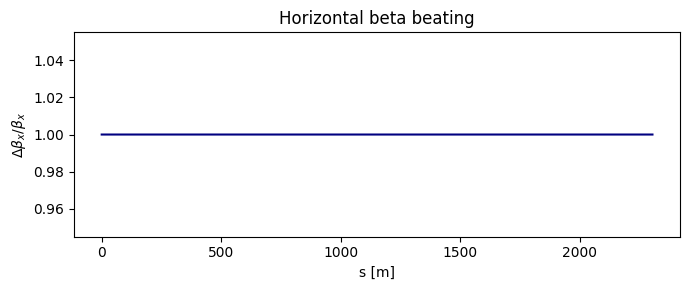

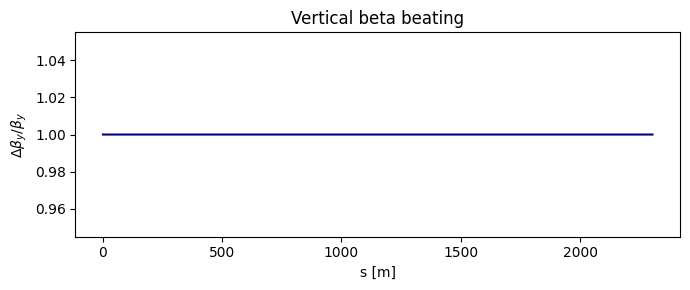

In [9]:
print('Lattice tune after loco :' , at.get_tune(ring))
_, _, twiss_err = at.get_optics(ring, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")